# Day 5 — Representation Learning & Embeddings

## Note 5.4 — CLIP: one space for images and text

### How to read this note

Run the cells from top to bottom, in order. Read each text cell before running the code cell under it.

Most code cells are short. Each one makes one thing or does one thing and prints what comes back. Look at it before moving on.

The **Questions to sit with** blocks are places to stop and think. Try to answer them in your own words.

Every number in the text of this note came from running this notebook on a CPU. On another machine a few numbers may differ in the last decimal place, and times will differ more.

This note stands alone. It downloads its own data and models and defines everything it uses.

**Before class:** this note downloads CLIP, which is **605 MB**. If your internet is slow, run the cell in Section 2 once before the session so the model is already saved on your machine. If the download is impossible, Section 2 shows a one-line switch to a much smaller model (94 MB); the note still runs, but the numbers will be lower than the ones written here.

### Learning goal and outcome

**Goal.** Understand how one model can put photos and sentences into the **same** embedding space, what that makes possible, and where it breaks.

**Outcome.** By the end you can load CLIP, embed photos and sentences, classify photos using only the *names* of the classes, search photos with a sentence and with another photo, show a case where CLIP's text side fails while its image side still works, test that claim photo by photo, and explain how CLIP's image encoder (a Vision Transformer) sees a photo.

### Objectives

By the end of this note you will be able to:

1. Draw CLIP's two-encoder design and say how contrastive training (note 5.3) shapes the shared space.
2. Use a model and its *processor* to turn photos and sentences into embeddings.
3. Build zero-shot classification by hand from class names and prompts.
4. Measure whether the wording of a prompt matters.
5. Search photos with a sentence, and with another photo.
6. Show a dataset where zero-shot fails but the image embeddings still work, and say why.
7. Check a difference between two models photo by photo with a sign test.
8. Explain how a Vision Transformer cuts a photo into patches, and how that leads to Day 6.

### Datasets used

**Imagenette** (160-pixel version, 99.0 MB download). A small, freely downloadable subset of ImageNet with 10 easy-to-tell-apart classes: tench (a fish), English springer (a dog), cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball and parachute. We use 50 photos per class from its validation folder, 500 photos in all.

Why: these are everyday objects with everyday names, the kind of thing people post photos of and write captions about. This is CLIP's home ground, where it should work well.

**Beans** (validation and test splits, 18.5 MB + 17.7 MB). The bean leaf photos from note 5.1, in three classes: angular leaf spot, bean rust, healthy. 133 photos as a labelled reference set, 128 as test photos.

Why: specialist farm photos with specialist class names. This is far from CLIP's home ground, and it is where we look for the place it breaks. Using the same data as note 5.1 also lets us compare CLIP with note 5.1's ImageNet CNN on the same photos.

**Models:** CLIP ViT-B/32 (605 MB) and ResNet-18 (46.8 MB, the same weights as note 5.1).

### Table of contents

1. Two encoders, one space
2. Loading CLIP
3. One photo and one sentence
4. Zero-shot classification, built by hand
5. Does the wording of the prompt matter?
6. Searching both ways
7. Where it breaks: bean leaves
8. Is the gap real? A photo-by-photo check
9. CLIP sees a photo as patches: the Vision Transformer
10. What to take away from Day 5

### Runtime budget

Times are for a laptop CPU. Downloads depend on your internet speed.

| Part | What happens | Time |
|---|---|---|
| Setup | imports, version check | under 1 minute |
| Downloads | Imagenette 99 MB, Beans 36 MB, CLIP 605 MB, ResNet-18 47 MB | 2–10 minutes, once |
| Sections 2–3 | load CLIP, embed one photo and one sentence | under 1 minute |
| Section 4 | embed 500 Imagenette photos | 1–2 minutes |
| Sections 5–6 | prompts, search | under 1 minute |
| Sections 7–8 | embed 261 bean photos with CLIP and ResNet-18 | 1–2 minutes |
| Section 9 | look inside the image encoder | under 1 minute |
| Whole note | | about 6 minutes of running after downloads, plus reading |

### Environment setup

To install exactly the versions this note was built with, remove the `#` at the start of the `%pip` line, run it once, then restart the kernel.

In [1]:
# Remove the "#" on the next line to install the pinned versions, then restart the kernel.
# %pip install torch==2.14.0 torchvision==0.29.0 transformers==5.18.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8 pillow==12.1.1 scipy==1.17.1

In [2]:
import importlib.metadata as md

PINNED = {"torch": "2.14.0", "torchvision": "0.29.0", "transformers": "5.18.0",
          "scikit-learn": "1.8.0", "numpy": "2.4.4", "pandas": "3.0.2",
          "matplotlib": "3.10.8", "pillow": "12.1.1", "scipy": "1.17.1"}

for package, wanted in PINNED.items():
    installed = md.version(package)
    status = "ok" if installed.split("+")[0] == wanted else "DIFFERENT"
    print(f"{package:14} pinned {wanted:8} installed {installed:12} {status}")

torch          pinned 2.14.0   installed 2.14.0+cpu   ok
torchvision    pinned 0.29.0   installed 0.29.0+cpu   ok
transformers   pinned 5.18.0   installed 5.18.0       ok
scikit-learn   pinned 1.8.0    installed 1.8.0        ok
numpy          pinned 2.4.4    installed 2.4.4        ok
pandas         pinned 3.0.2    installed 3.0.2        ok
matplotlib     pinned 3.10.8   installed 3.10.8       ok
pillow         pinned 12.1.1   installed 12.1.1       ok
scipy          pinned 1.17.1   installed 1.17.1       ok


### Environment detection

This cell finds which hardware PyTorch could use (`cuda`, `mps` or `cpu`), and then the note uses the **CPU on purpose** so your numbers match the ones written here. CLIP on 500 small photos is comfortable on a laptop CPU.

In [3]:
import torch

if torch.cuda.is_available():
    FOUND = "cuda"
elif torch.backends.mps.is_available():
    FOUND = "mps"
else:
    FOUND = "cpu"

DEVICE = "cpu"   # chosen on purpose, so numbers match this note
print("Best hardware found on this machine:", FOUND)
print("Hardware this note will use:        ", DEVICE)
print("CPU threads PyTorch can use:        ", torch.get_num_threads())

Best hardware found on this machine: cpu
Hardware this note will use:         cpu
CPU threads PyTorch can use:         1


In [4]:
import time, tarfile, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from PIL import Image
from scipy.stats import binomtest
from sklearn.neighbors import KNeighborsClassifier

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
print("Data will be saved in:", DATA_DIR.resolve())

Data will be saved in: /home/claude/day5/run_clean/data


### Downloading the photos

Imagenette comes as a `.tgz` file: many files packed together and compressed. `tarfile.open(path)` opens it and `.extractall(folder)` unpacks it. The `filter="data"` argument tells Python to unpack only ordinary files, which is the safe setting for archives downloaded from the internet.

In [5]:
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
tgz_path = DATA_DIR / "imagenette2-160.tgz"
if not tgz_path.exists():
    urllib.request.urlretrieve(IMAGENETTE_URL, tgz_path)
print(f"{tgz_path.name}: {tgz_path.stat().st_size / 1e6:.1f} MB")

if not (DATA_DIR / "imagenette2-160").exists():
    with tarfile.open(tgz_path) as archive:
        archive.extractall(DATA_DIR, filter="data")
print(sorted(p.name for p in (DATA_DIR / "imagenette2-160").iterdir()))

imagenette2-160.tgz: 99.0 MB


['.DS_Store', 'noisy_imagenette.csv', 'train', 'val']


The Beans photos, exactly as in note 5.1:

In [6]:
BEANS_URL = "https://huggingface.co/datasets/AI-Lab-Makerere/beans/resolve/main/data/{split}.zip"
BEANS_DIR = DATA_DIR / "beans"
for split in ["validation", "test"]:
    zip_path = DATA_DIR / f"beans_{split}.zip"
    if not zip_path.exists():
        urllib.request.urlretrieve(BEANS_URL.format(split=split), zip_path)
    if not (BEANS_DIR / split).exists():
        zipfile.ZipFile(zip_path).extractall(BEANS_DIR)
    print(f"{zip_path.name:24} {zip_path.stat().st_size / 1e6:5.1f} MB")

beans_validation.zip      18.5 MB
beans_test.zip            17.7 MB


Imagenette names its class folders with ImageNet codes like `n01440764`. We give each code a plain English name, which is all that zero-shot classification will get to know about each class.

In [7]:
IMAGENETTE_NAMES = {
    "n01440764": "tench", "n02102040": "English springer", "n02979186": "cassette player",
    "n03000684": "chain saw", "n03028079": "church", "n03394916": "French horn",
    "n03417042": "garbage truck", "n03425413": "gas pump", "n03445777": "golf ball",
    "n03888257": "parachute",
}
CODES = sorted(IMAGENETTE_NAMES)
NAMES = [IMAGENETTE_NAMES[c] for c in CODES]
print(NAMES)

['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


We take the first 50 files (in sorted order, so everyone gets the same ones) from each class's validation folder. The `assert` line at the end stops the notebook with a message if any class folder is missing or short, so a typo in a folder code cannot quietly shrink the data. `.convert("RGB")` makes sure every photo has three colour channels; a few files in such collections are stored in grey.

In [8]:
net_photos, net_labels = [], []
for label, code in enumerate(CODES):
    files = sorted((DATA_DIR / "imagenette2-160" / "val" / code).glob("*.JPEG"))[:50]
    for f in files:
        net_photos.append(Image.open(f).convert("RGB"))
        net_labels.append(label)
net_labels = np.array(net_labels)
assert np.all(np.bincount(net_labels) == 50), "a class folder is missing or short"
print("Imagenette photos:", len(net_photos), " per class:", np.bincount(net_labels).tolist())
print("Size of the first photo:", net_photos[0].size)

Imagenette photos: 500  per class: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Size of the first photo: (213, 160)


In [9]:
BEAN_CLASSES = sorted(p.name for p in (BEANS_DIR / "validation").iterdir())

def load_bean_photos(split):
    photos, labels = [], []
    for label, name in enumerate(BEAN_CLASSES):
        for f in sorted((BEANS_DIR / split / name).glob("*.jpg")):
            photos.append(Image.open(f).convert("RGB"))
            labels.append(label)
    return photos, np.array(labels)

bean_ref_photos, bean_ref_labels = load_bean_photos("validation")
bean_test_photos, bean_test_labels = load_bean_photos("test")
print("Bean classes:", BEAN_CLASSES)
print("Bean reference photos:", len(bean_ref_photos), " test photos:", len(bean_test_photos))

Bean classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Bean reference photos: 133  test photos: 128


## 1. Two encoders, one space

In note 5.1 we turned photos into vectors. In note 5.2 we turned sentences into vectors. Those were two different spaces: a photo vector and a sentence vector could not be compared, any more than you can compare a temperature with a price.

**CLIP** (*Contrastive Language–Image Pre-training*) builds one space for both. It has two encoders:

```
 photo  ──▶  IMAGE ENCODER (a Vision Transformer) ──▶ 512 numbers ─┐
                                                                   ├─▶  ONE SHARED SPACE
 text   ──▶  TEXT ENCODER  (a text Transformer)   ──▶ 512 numbers ─┘    (compare with cosine)
```

The two encoders are trained **together**, with the contrastive loss you wrote in note 5.3. Each training batch is a set of photos and the captions that were posted with them on the web. For every photo, its own caption is the positive and every other caption in the batch is a negative, and the same the other way round. The batch similarity matrix from note 5.3 is now *photos down the side, captions along the top*, and training makes the diagonal win.

After training on about 400 million photo–caption pairs, a photo of a church and the sentence "a photo of a church" end up pointing in nearly the same direction, even though one came from pixels and the other from letters.

<div align="center">

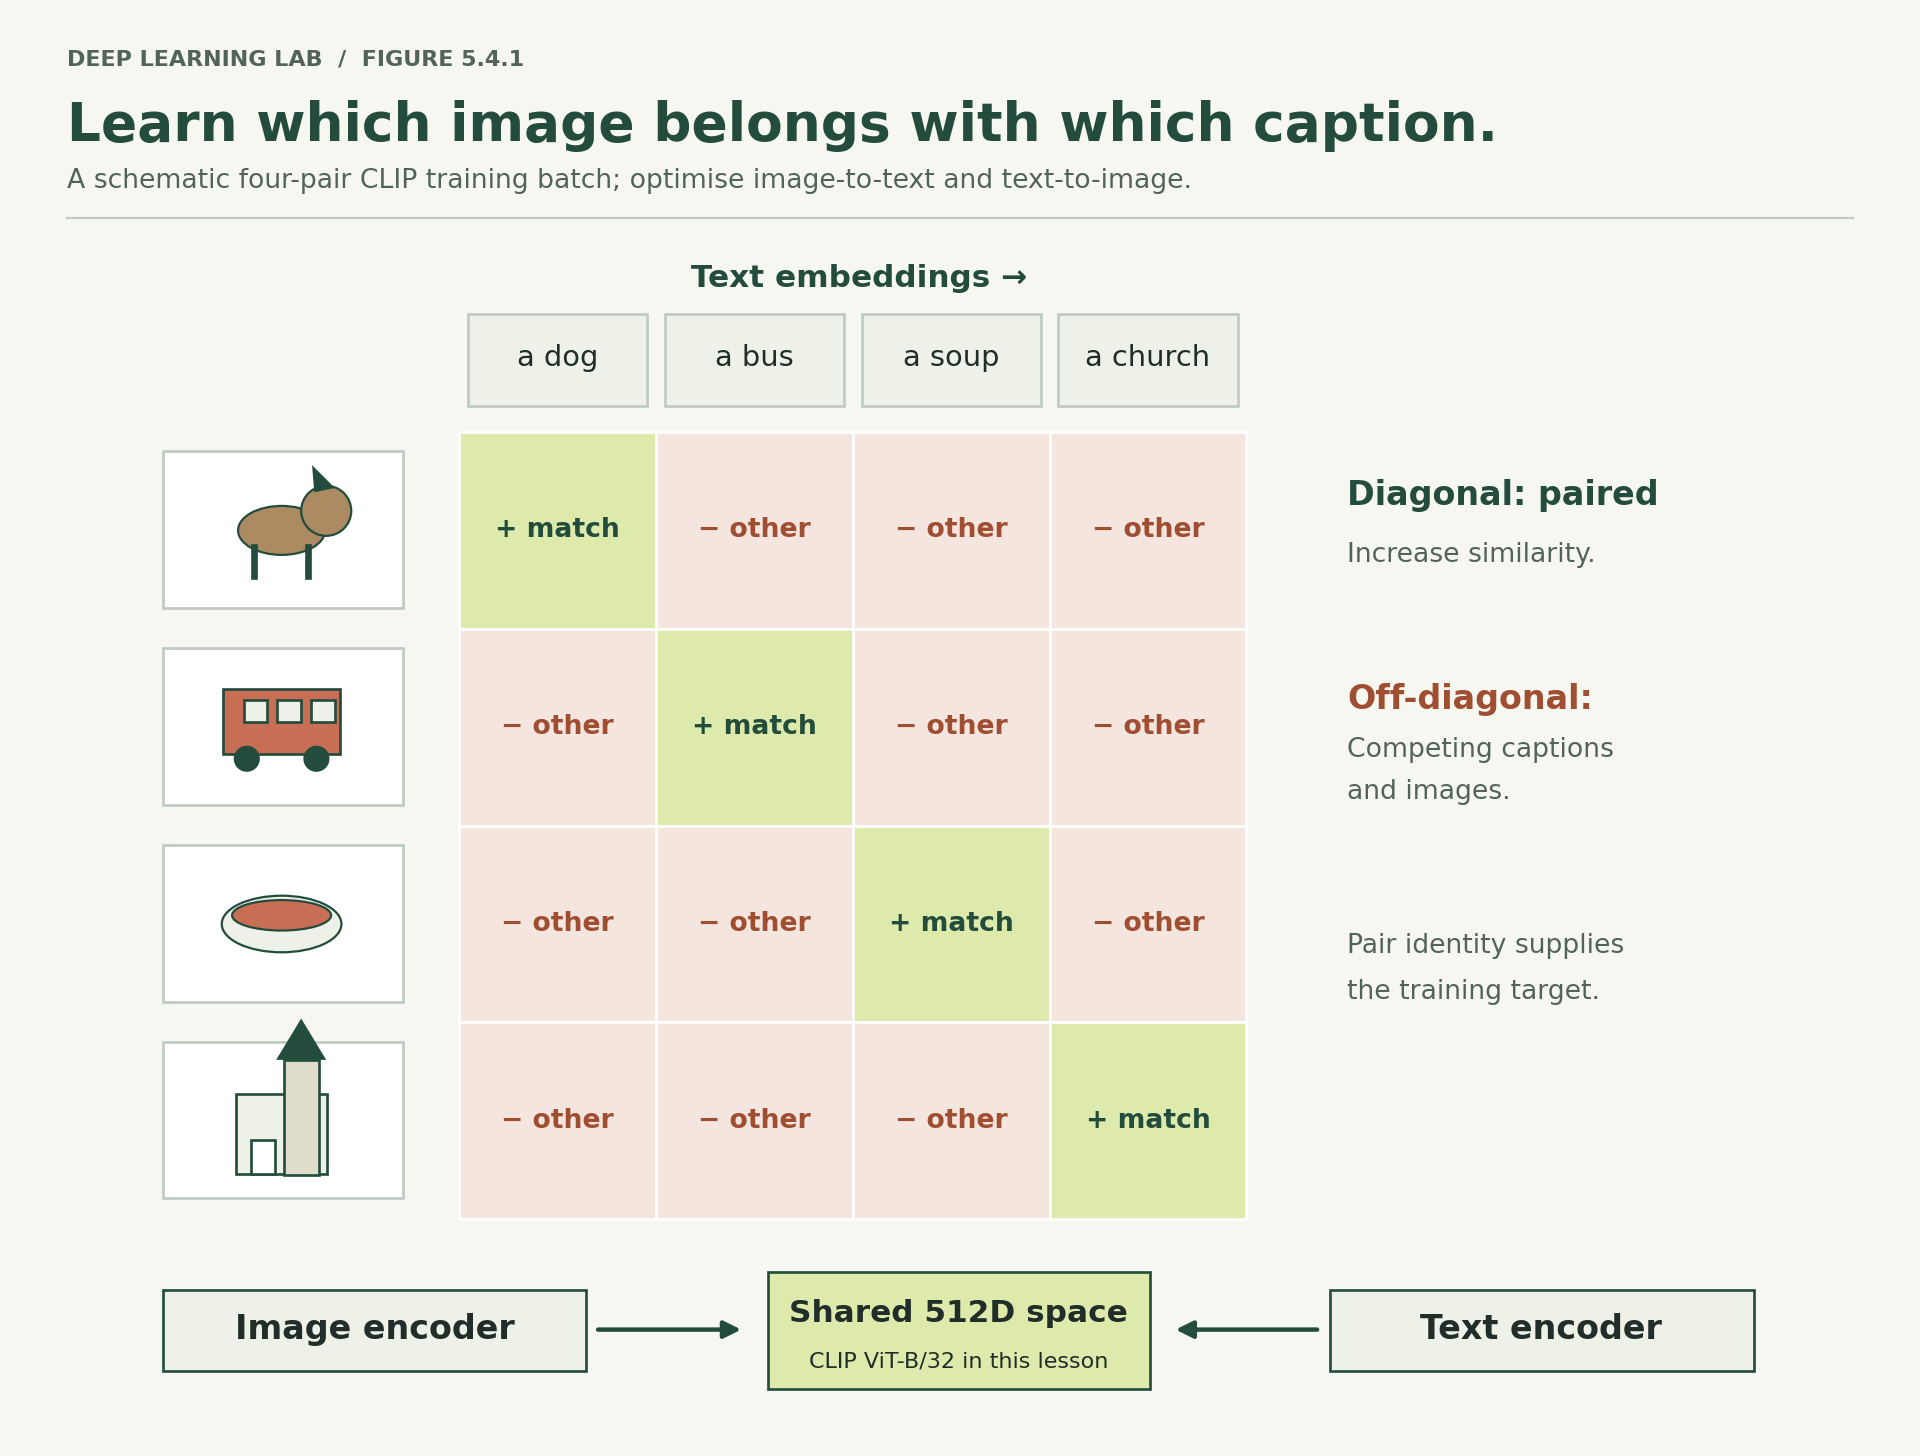

<p><b>Figure 5.4.1.</b> CLIP uses paired images and captions as contrastive targets in both directions. The icons represent example images; the matrix shows pair roles, not measured scores.</p>

</div>

## 2. Loading CLIP

We use `CLIPModel` and `CLIPProcessor` from the `transformers` library (the library underneath `sentence-transformers` in note 5.2).

- `CLIPModel.from_pretrained(name)` downloads the trained weights from the Hugging Face Hub (the first time) and builds the model. Day 7 covers `from_pretrained` and the Hub properly.
- `CLIPProcessor.from_pretrained(name)` loads the matching **processor**: the code that prepares inputs exactly the way this model was trained. For photos, it resizes, crops and normalises. For text, it is a tokenizer (note 5.2).

The model is `openai/clip-vit-base-patch32`: the standard CLIP, whose image encoder is a ViT-B/32 (Section 9 explains the name).

If you cannot download 605 MB, set `USE_SMALL_CLIP = True`. That switches to TinyCLIP, a compressed CLIP of 94 MB. Everything below still runs, but the numbers written in this note were made with the full model.

In [10]:
from transformers import CLIPModel, CLIPProcessor

USE_SMALL_CLIP = False
CLIP_NAME = "wkcn/TinyCLIP-ViT-8M-16-Text-3M-YFCC15M" if USE_SMALL_CLIP else "openai/clip-vit-base-patch32"

start = time.perf_counter()
model = CLIPModel.from_pretrained(CLIP_NAME).eval()
processor = CLIPProcessor.from_pretrained(CLIP_NAME)
print("Loaded", CLIP_NAME, f"in {time.perf_counter() - start:.1f} s")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 16069.36it/s]

Loaded openai/clip-vit-base-patch32 in 8.1 s


`.eval()` puts the model in evaluation mode (note 5.1), because we are only using it, not training it.

Let us count the weights in each part. `model.vision_model` is the image encoder and `model.text_model` the text encoder. Each ends with a small extra layer, `visual_projection` and `text_projection`, that maps its output into the shared 512-number space.

In [11]:
def count(module):
    return sum(p.numel() for p in module.parameters())

print(f"Image encoder:     {count(model.vision_model):>12,}")
print(f"Text encoder:      {count(model.text_model):>12,}")
print(f"Image projection:  {count(model.visual_projection):>12,}   {model.visual_projection}")
print(f"Text projection:   {count(model.text_projection):>12,}   {model.text_projection}")
print(f"Whole model:       {count(model):>12,}")

Image encoder:       87,456,000
Text encoder:        63,165,952
Image projection:       393,216   Linear(in_features=768, out_features=512, bias=False)
Text projection:        262,144   Linear(in_features=512, out_features=512, bias=False)
Whole model:        151,277,313


About **151 million** weights in all: the image encoder has 87.5 million and the text encoder 63.2 million. Compare MiniLM in note 5.2 with 22.7 million. Add up the five lines and one weight is left over: it is `logit_scale`, a single learned number you will meet in Section 3.

### What the processor does

Give the processor one photo and see what comes back. `return_tensors="pt"` asks for PyTorch tensors.

In [12]:
photo_inputs = processor(images=[net_photos[0]], return_tensors="pt")
print("Keys:", list(photo_inputs.keys()))
print("pixel_values shape:", tuple(photo_inputs["pixel_values"].shape))

Keys: ['pixel_values']
pixel_values shape: (1, 3, 224, 224)


The 160 × 160 Imagenette photo became a `(1, 3, 224, 224)` tensor: one photo, three colour channels, 224 × 224 pixels. That is the size CLIP's image encoder was trained on.

And one sentence:

In [13]:
text_inputs = processor(text=["a photo of a church"], return_tensors="pt", padding=True)
print("Keys:", list(text_inputs.keys()))
print("input_ids:", text_inputs["input_ids"])
print("tokens:   ", processor.tokenizer.convert_ids_to_tokens(text_inputs["input_ids"][0]))

Keys: ['input_ids', 'attention_mask']
input_ids: tensor([[49406,   320,  1125,   539,   320,  2735, 49407]])
tokens:    ['<|startoftext|>', 'a</w>', 'photo</w>', 'of</w>', 'a</w>', 'church</w>', '<|endoftext|>']


Like MiniLM's tokenizer in note 5.2, CLIP's tokenizer adds start and end markers (`<|startoftext|>` and `<|endoftext|>`). The `</w>` at the end of each piece marks the end of a word. `padding=True` fills short sentences up to the length of the longest one in the batch, so a batch of different-length sentences fits in one tensor.

## 3. One photo and one sentence

`model.get_image_features(pixel_values=...)` runs the image encoder and its projection. `model.get_text_features(input_ids=..., attention_mask=...)` does the same for text.

In this version of `transformers`, each method returns an object holding two results:

- `last_hidden_state`: one vector for every piece of the input (Section 9 looks at this for photos);
- `pooler_output`: the final **512-number embedding** in the shared space. This is the one we want.

In [14]:
with torch.no_grad():
    image_out = model.get_image_features(pixel_values=photo_inputs["pixel_values"])
    text_out = model.get_text_features(**text_inputs)
print("Image result holds:", list(image_out.keys()))
print("Image embedding:", tuple(image_out.pooler_output.shape))
print("Text embedding: ", tuple(text_out.pooler_output.shape))

Image result holds: ['last_hidden_state', 'pooler_output']
Image embedding: (1, 512)
Text embedding:  (1, 512)


Both are 512 numbers long, in the same space. Now two helper functions that embed many photos or many sentences, in batches, and normalise each embedding to length 1 so that dot products are cosine similarities (note 5.2). `F.normalize` is not imported here, so we divide by `.norm(dim=1, keepdim=True)` directly, which does the same thing.

In [15]:
def embed_photos(photos, batch_size=32):
    chunks = []
    with torch.no_grad():
        for start in range(0, len(photos), batch_size):
            inputs = processor(images=photos[start:start + batch_size], return_tensors="pt")
            chunks.append(model.get_image_features(pixel_values=inputs["pixel_values"]).pooler_output)
    vectors = torch.cat(chunks)
    return (vectors / vectors.norm(dim=1, keepdim=True)).numpy()

def embed_texts(texts):
    with torch.no_grad():
        inputs = processor(text=texts, return_tensors="pt", padding=True)
        vectors = model.get_text_features(**inputs).pooler_output
    return (vectors / vectors.norm(dim=1, keepdim=True)).numpy()

Take one photo from the `church` class and compare it with three sentences.

In [16]:
church_photo = net_photos[NAMES.index("church") * 50]
sentences = ["a photo of a church", "a photo of a dog", "a photo of a golf ball"]
p = embed_photos([church_photo])
t = embed_texts(sentences)
for s, score in zip(sentences, (t @ p[0])):
    print(f"{score:.4f}  {s}")

0.2707  a photo of a church
0.2023  a photo of a dog
0.1573  a photo of a golf ball


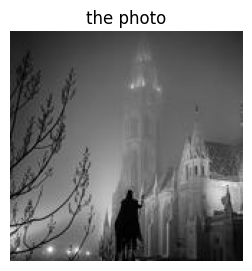

In [17]:
plt.figure(figsize=(3, 3)); plt.imshow(church_photo); plt.axis("off"); plt.title("the photo"); plt.show()

The right sentence wins: **0.2707** for the church, against 0.2023 for the dog and 0.1573 for the golf ball.

But look at how small these numbers are. A photo and a sentence that describes it perfectly score only 0.27. In CLIP's space, photo vectors and sentence vectors sit in two different regions, and they only *lean* towards each other. So, as in note 5.2, the size of a cosine score means little on its own. What matters is the **order**: which sentence is highest for this photo.

### CLIP's temperature

In note 5.3, the contrastive loss divided the cosine scores by a temperature (0.2) to stretch them. CLIP *learned* its temperature during training. It is stored as `model.logit_scale`, as the logarithm of 1 / temperature, so we take `.exp()` to undo the logarithm.

In [18]:
scale = model.logit_scale.exp().item()
print(f"CLIP multiplies cosine scores by {scale:.2f}, which means a temperature of {1 / scale:.4f}")

CLIP multiplies cosine scores by 100.00, which means a temperature of 0.0100


CLIP's temperature is **0.0100**, much smaller than our 0.2 in note 5.3. That makes sense given the small scores above. A gap of 0.07 between the church and the dog sentences becomes a gap of about 7 after multiplying by 100, and softmax turns a gap of 7 into a very confident choice. The next section shows this.

## 4. Zero-shot classification, built by hand

**Zero-shot classification** means classifying photos into classes the model was never trained on as classes, using **no labelled examples at all**. All CLIP gets is the class names.

The recipe has three steps:

1. Turn each class name into a sentence called a **prompt**, such as "a photo of a church.", and embed every prompt.
2. Embed every photo.
3. For each photo, the predicted class is the prompt it is most similar to.

```
 class names ──▶ prompts ──▶ TEXT ENCODER  ──▶ 10 text vectors ─┐
                                                                ├──▶ similarity matrix (500 × 10) ──▶ argmax ──▶ class
 photos ──────────────────▶ IMAGE ENCODER ──▶ 500 photo vectors ┘
```

In [19]:
prompts = [f"a photo of a {name}." for name in NAMES]
text_vectors = embed_texts(prompts)
print("Prompts:", prompts[:3], "...")
print("Text vectors:", text_vectors.shape)

Prompts: ['a photo of a tench.', 'a photo of a English springer.', 'a photo of a cassette player.'] ...
Text vectors: (10, 512)


In [20]:
start = time.perf_counter()
photo_vectors = embed_photos(net_photos)
print("Photo vectors:", photo_vectors.shape)
print(f"Embedded {len(net_photos)} photos in {time.perf_counter() - start:.1f} s")

Photo vectors: (500, 512)
Embedded 500 photos in 55.8 s


Now every photo against every prompt in one matrix multiplication, as in note 5.2. `.argmax(axis=1)` picks the best prompt for each photo.

In [21]:
scores = photo_vectors @ text_vectors.T
print("Score matrix:", scores.shape, "  (photos × classes)")
predicted = scores.argmax(axis=1)
zero_shot_acc = (predicted == net_labels).mean()
print(f"Zero-shot accuracy on Imagenette: {zero_shot_acc:.4f}")
print(f"Random guessing:                  {1 / len(NAMES):.4f}")

Score matrix: (500, 10)   (photos × classes)
Zero-shot accuracy on Imagenette: 0.9780
Random guessing:                  0.1000


**0.9780**: 489 of 500 photos correct, against 0.1000 for random guessing, and **not one labelled training example**. CLIP was never trained to sort photos into these 10 classes. It only learned, from captions, which words go with which photos.

To turn one photo's row of scores into probabilities, CLIP multiplies by its scale (Section 3) and applies softmax, the same step as in note 5.3's loss.

In [22]:
row = torch.tensor(scores[0] * scale)
probabilities = torch.softmax(row, dim=0).numpy()
for name, prob in sorted(zip(NAMES, probabilities), key=lambda x: -x[1])[:3]:
    print(f"{prob:.4f}  {name}")
print("True class:", NAMES[net_labels[0]])

0.9853  tench
0.0142  chain saw
0.0002  gas pump
True class: tench


Which classes does it get wrong, and what does it confuse them with? We count mistakes per true class.

In [23]:
mistakes = pd.DataFrame({"true": [NAMES[i] for i in net_labels], "predicted": [NAMES[i] for i in predicted]})
mistakes = mistakes[mistakes["true"] != mistakes["predicted"]]
print("Total mistakes:", len(mistakes))
mistakes.value_counts().rename("count").reset_index()

Total mistakes: 11


,true,predicted,count
0,gas pump,cassette player,2
1,golf ball,chain saw,2
2,English springer,tench,1
3,English springer,chain saw,1
4,cassette player,chain saw,1
5,cassette player,French horn,1
6,chain saw,tench,1
7,chain saw,garbage truck,1
8,parachute,French horn,1


Only 11 mistakes, spread thinly: no single confusion happens more than twice. With mistakes this rare and this scattered, there is no clear weakness to fix on this data. It is CLIP's home ground.

> **Questions to sit with**
>
> 1. CLIP was never trained to sort photos into these 10 classes. What exactly did it use to do it?
> 2. To add an 11th class, say "a photo of a bicycle", what would you need to do? Compare that with what adding a class would take for the CNN in note 5.1.

## 5. Does the wording of the prompt matter?

CLIP learned from web captions, and captions rarely say just "church". So the wording of the prompt might matter. We compare the bare class name with the "a photo of a ..." template on the same 500 photos, and count photo by photo, as in notes 5.1 and 5.2.

In [24]:
def zero_shot(prompt_list, photo_vecs):
    return (photo_vecs @ embed_texts(prompt_list).T).argmax(axis=1)

bare = zero_shot(NAMES, photo_vectors)
template = zero_shot([f"a photo of a {n}." for n in NAMES], photo_vectors)
right_bare, right_template = bare == net_labels, template == net_labels

print(f"Bare names ('church'):                 {right_bare.mean():.4f}")
print(f"Template ('a photo of a church.'):     {right_template.mean():.4f}")
print("Right only with template:", np.sum(right_template & ~right_bare),
      "  right only with bare name:", np.sum(right_bare & ~right_template))

Bare names ('church'):                 0.9820
Template ('a photo of a church.'):     0.9780
Right only with template: 0   right only with bare name: 2


The template did **not** help here. Bare names scored **0.9820** and the template **0.9780**. Photo by photo, the bare names won the only 2 photos on which the two disagreed.

The common advice to write "a photo of a ..." came from tests on harder datasets. On these 10 easy classes, accuracy is already close to the ceiling, so there is almost nothing left for wording to fix. That is the lesson: prompt advice is a guess to test on your own data, not a rule.

> **Questions to sit with**
>
> 1. Our template produced "a photo of a English springer." (should be "an"). Could small slips like that matter? How would you find out without tuning on the test photos?
> 2. Two photos out of 500 is a very small difference. Would you change a production system on that evidence?

## 6. Searching both ways

Because photos and sentences live in one space, we can search photos **with a sentence**. This is note 5.2's search, with photos as the stored items.

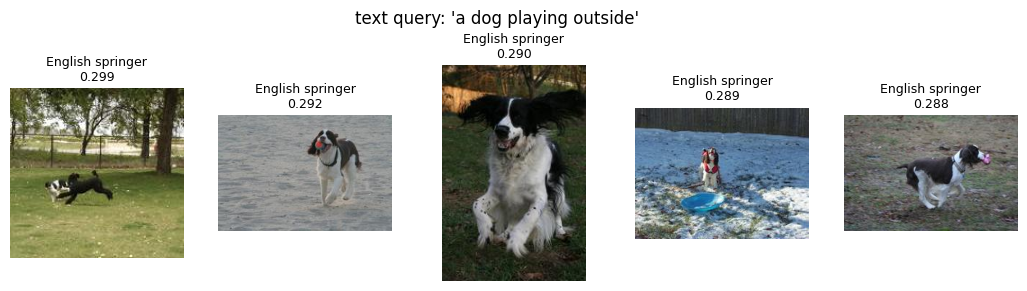

In [25]:
def show_photos(indices, scores_list, title):
    fig, axes = plt.subplots(1, len(indices), figsize=(2.6 * len(indices), 2.8))
    for ax, i, s in zip(axes, indices, scores_list):
        ax.imshow(net_photos[i]); ax.axis("off")
        ax.set_title(f"{NAMES[net_labels[i]]}\n{s:.3f}", fontsize=9)
    fig.suptitle(title, y=1.08)
    plt.show()

def search_photos_with_text(query, k=5):
    q = embed_texts([query])[0]
    s = photo_vectors @ q
    top = np.argsort(-s)[:k]
    show_photos(top, s[top], f"text query: {query!r}")

search_photos_with_text("a dog playing outside")

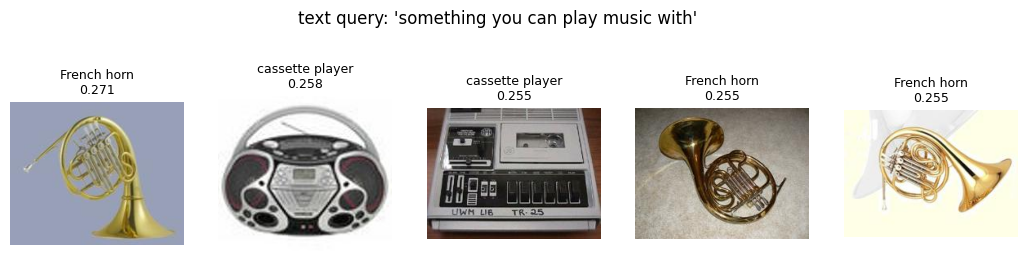

In [26]:
search_photos_with_text("something you can play music with")

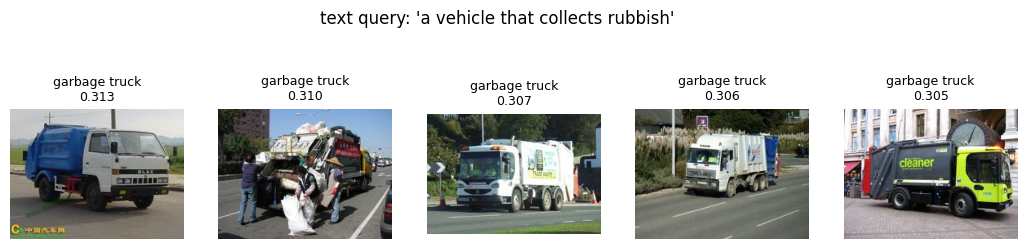

In [27]:
search_photos_with_text("a vehicle that collects rubbish")

All 15 results are right. The second query is the interesting one: "something you can play music with" names no object, yet CLIP returns French horns *and* cassette players, two very different-looking objects that share a use. It learned that from how people write about photos.

Notice the scores again: between about 0.25 and 0.31, as in Section 3. Photo-to-sentence scores in CLIP stay small even when the match is perfect.

### Searching photos with a photo

We can also use one photo as the query. This only uses the image encoder, so it is the same kind of search as note 5.1's nearest neighbours, but with CLIP's image embeddings. We skip the first result, because the closest photo to a photo is always itself.

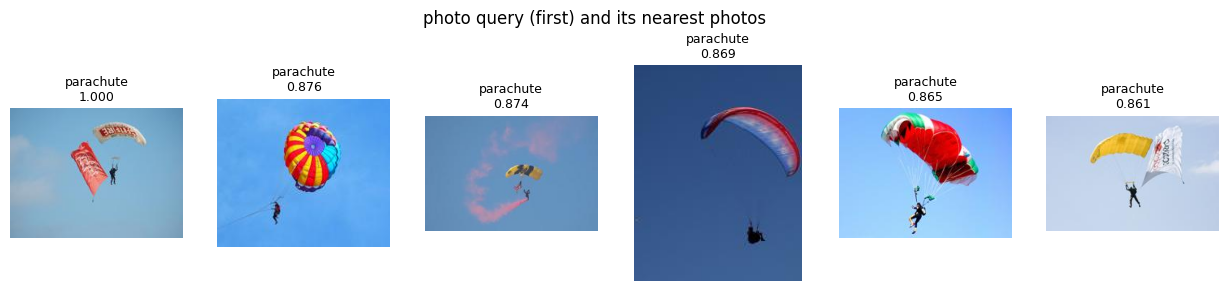

In [28]:
def search_photos_with_photo(index, k=5):
    s = photo_vectors @ photo_vectors[index]
    top = np.argsort(-s)[1:k + 1]
    show_photos([index] + list(top), [1.0] + list(s[top]), "photo query (first) and its nearest photos")

search_photos_with_photo(NAMES.index("parachute") * 50)

All five nearest photos are parachutes, with scores between **0.861** and **0.876**. Those scores are far higher than the photo-to-sentence scores above (about 0.25 to 0.31). Photos are much closer to other photos than to any sentence, which is the "two regions" effect from Section 3, seen directly. Never compare a photo-to-photo score with a photo-to-text score as if they were on the same scale.

> **Questions to sit with**
>
> 1. "Something you can play music with" never names an object. How can CLIP still find French horns and cassette players?
> 2. What would you need to build a search engine for a company's own product photos, using only what is in this note?

## 7. Where it breaks: bean leaves

Now the bean photos from note 5.1. The classes are *angular leaf spot*, *bean rust* and *healthy*. We write prompts in the same style as before.

In [29]:
bean_prompts = ["a photo of a bean leaf with angular leaf spot.",
                "a photo of a bean leaf with bean rust.",
                "a photo of a healthy bean leaf."]
bean_test_vectors = embed_photos(bean_test_photos)
bean_pred = zero_shot(bean_prompts, bean_test_vectors)
print(f"Zero-shot accuracy on Beans: {(bean_pred == bean_test_labels).mean():.4f}")
print(f"Random guessing:             {1/3:.4f}")
print("How often each class was predicted:", dict(zip(BEAN_CLASSES, np.bincount(bean_pred, minlength=3).tolist())))

Zero-shot accuracy on Beans: 0.3047
Random guessing:             0.3333
How often each class was predicted: {'angular_leaf_spot': 32, 'bean_rust': 96, 'healthy': 0}


**0.3047**, *below* random guessing (0.3333). CLIP predicted "bean rust" for 96 of the 128 photos and **never once** predicted "healthy", even though 42 of the test photos are healthy leaves.

This is what "zero-shot breaks" looks like. Leaf-disease names are rare in web captions, and photos like these, taken in fields for plant scientists, are rare on the web. CLIP's text side does not know where in the space "angular leaf spot" belongs.

Perhaps CLIP does not know the disease *names*, but would recognise a *description* of what the leaves look like. Let us describe them instead of naming them.

In [30]:
described = ["a photo of a green leaf with small brown angular spots.",
             "a photo of a leaf covered in small rusty orange-brown spots.",
             "a photo of a healthy, clean, green leaf."]
described_pred = zero_shot(described, bean_test_vectors)
print(f"Zero-shot with described prompts: {(described_pred == bean_test_labels).mean():.4f}")
print("How often each class was predicted:", dict(zip(BEAN_CLASSES, np.bincount(described_pred, minlength=3).tolist())))

Zero-shot with described prompts: 0.2188
How often each class was predicted: {'angular_leaf_spot': 78, 'bean_rust': 49, 'healthy': 1}


It got **worse**: **0.2188**, with "angular leaf spot" now predicted for 78 photos and "healthy" for just 1.

So plain-language descriptions did not rescue it either. There is also a trap here. We could keep rewording the prompts until the test score goes up, but then the prompts would be *tuned on the test photos*, the same mistake as choosing `C` on test data in note 5.2. One honest attempt is a fair test; twenty attempts on the test set is not.

### Is the problem the text side or the image side?

Zero-shot uses both encoders. If it fails, either the photo vectors are poor, or the text vectors do not land where the photo vectors are, or both. We can test the image side on its own: forget the text, and run note 5.1's 5-nearest-neighbour test on CLIP's **photo** vectors, using the 133 labelled reference photos.

For unit vectors, the smallest Euclidean distance gives the same ranking as the largest cosine similarity, so the default kNN is fine here.

In [31]:
bean_ref_vectors = embed_photos(bean_ref_photos)
knn = KNeighborsClassifier(n_neighbors=5).fit(bean_ref_vectors, bean_ref_labels)
clip_knn_pred = knn.predict(bean_test_vectors)
print(f"5-NN on CLIP photo vectors: {(clip_knn_pred == bean_test_labels).mean():.4f}")

5-NN on CLIP photo vectors: 0.8516


**0.8516**. The same photo vectors that failed at zero-shot do well as soon as they are compared with 133 labelled photos instead of with sentences. So CLIP's **image side is fine**. Its photo vectors do put similar leaves near each other. What failed is the **link between the text side and these photos**: the prompts land in the wrong places.

This is a useful habit. When a two-part system fails, test each part separately before deciding what is broken.

## 8. Is the gap real? A photo-by-photo check

In note 5.1, 5-nearest-neighbours on ResNet-18's ImageNet features scored 0.7969 on these same test photos. Is CLIP's image side better? Let us rebuild note 5.1's ResNet-18 features here (same weights, same preparation) and compare on the same 128 photos.

`transforms.Resize((224, 224))`, `ToTensor()` and `Normalize(...)` are exactly the steps from note 5.1. Replacing `fc` with `nn.Identity()` returns the 512 numbers before the last layer.

In [32]:
import torchvision
from torchvision import transforms

prepare = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                              transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()
resnet.eval()

def resnet_features(photos, batch_size=32):
    out = []
    with torch.no_grad():
        for start in range(0, len(photos), batch_size):
            out.append(resnet(torch.stack([prepare(p) for p in photos[start:start + batch_size]])))
    return torch.cat(out).numpy()

R_ref, R_test = resnet_features(bean_ref_photos), resnet_features(bean_test_photos)
resnet_pred = KNeighborsClassifier(n_neighbors=5).fit(R_ref, bean_ref_labels).predict(R_test)
print(f"5-NN on ResNet-18 features: {(resnet_pred == bean_test_labels).mean():.4f}")

5-NN on ResNet-18 features: 0.7969


That matches note 5.1's number, so we are comparing like with like. Now the sign test from note 5.1: count the photos where exactly one of the two is right.

In [33]:
right_clip = clip_knn_pred == bean_test_labels
right_resnet = resnet_pred == bean_test_labels
only_clip = int(np.sum(right_clip & ~right_resnet))
only_resnet = int(np.sum(right_resnet & ~right_clip))
print("Right with both:", int(np.sum(right_clip & right_resnet)), "  wrong with both:", int(np.sum(~right_clip & ~right_resnet)))
print("Right only with CLIP:", only_clip, "  right only with ResNet-18:", only_resnet)
print(f"Sign-test p-value: {binomtest(only_clip, only_clip + only_resnet, 0.5).pvalue:.4f}")

Right with both: 93   wrong with both: 10
Right only with CLIP: 16   right only with ResNet-18: 9
Sign-test p-value: 0.2295


The two models agree on most photos (93 right with both, 10 wrong with both). Of the 25 photos where they disagree, CLIP wins 16 and ResNet-18 wins 9. The p-value is **0.2295**: a fair coin would give a split at least this uneven nearly a quarter of the time.

So **we cannot say CLIP's photo vectors are better than ResNet-18's on these bean leaves.** 0.8516 against 0.7969 looks like a clear gap, but on 128 photos it is only a 7-photo difference, and the sign test says that could easily be chance. Both are good, learned representations; this test set is too small to rank them. The fair conclusion is the boring one, and it is worth writing down exactly like that.

> **Questions to sit with**
>
> 1. A colleague says "CLIP is useless for crop disease, it scored below chance." Using Sections 7 and 8, what would you tell them?
> 2. If you needed CLIP's zero-shot to work on bean disease, what would you need to change: the photos, the prompts, or the model? (Day 7 and Day 8 are about the last option.)

## 9. CLIP sees a photo as patches: the Vision Transformer

CLIP's image encoder is not a CNN. It is a **Vision Transformer (ViT)**, the step after CNNs on note 5.1's timeline. Its name, ViT-B/32, says how it works: **B** is the "base" size, and **32** means it cuts every photo into squares of 32 × 32 pixels, called **patches**.

The model's settings are stored in `model.config.vision_config`.

In [34]:
vision = model.config.vision_config
patches_per_side = vision.image_size // vision.patch_size
print("Photo size:", vision.image_size, " patch size:", vision.patch_size)
print("Patches per side:", patches_per_side, " patches in total:", patches_per_side ** 2)
print("Numbers per patch vector:", vision.hidden_size)

Photo size: 224  patch size: 32
Patches per side: 7  patches in total: 49
Numbers per patch vector: 768


A 224 × 224 photo cut into 32 × 32 squares gives a 7 × 7 grid: 49 patches. Let us draw the grid on the photo the model actually sees (after the processor's resize and crop). `plt.axhline` and `plt.axvline` draw horizontal and vertical lines.

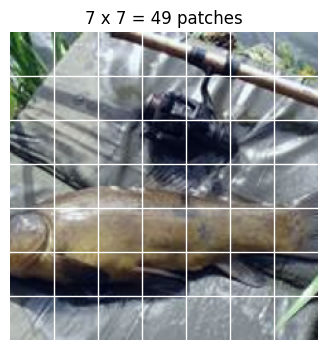

In [35]:
seen = photo_inputs["pixel_values"][0].permute(1, 2, 0).numpy()
seen = (seen - seen.min()) / (seen.max() - seen.min())    # undo normalising, for display only
plt.figure(figsize=(4, 4))
plt.imshow(seen)
for k in range(1, patches_per_side):
    plt.axhline(k * vision.patch_size - 0.5, color="white", linewidth=1)
    plt.axvline(k * vision.patch_size - 0.5, color="white", linewidth=1)
plt.title(f"{patches_per_side} x {patches_per_side} = {patches_per_side**2} patches"); plt.axis("off")
plt.show()

Each patch is flattened and turned into one vector, like a word becomes a token vector in note 5.2. The Transformer then treats the 49 patches like a sentence of 49 "words". One extra vector called the **class token** is added at the front; it collects information from all the patches and becomes the photo's summary. So we expect 50 vectors.

`model.vision_model(pixel_values=...)` runs the image encoder without the final projection, and `last_hidden_state` holds one vector per position.

In [36]:
with torch.no_grad():
    vision_out = model.vision_model(pixel_values=photo_inputs["pixel_values"])
print("last_hidden_state shape:", tuple(vision_out.last_hidden_state.shape))

last_hidden_state shape: (1, 50, 768)


**50 vectors of 768 numbers**: one for the class token, then one for each of the 49 patches. After the Transformer, the class token's 768 numbers go through `visual_projection` (768 → 512, Section 2), and that gives the 512-number photo embedding we used all through this note.

Inside the Transformer, every patch compares itself with every other patch, using **attention**, so a patch showing part of a church spire can take information from the patch showing the rest of it. That comparison step is exactly what Day 6 opens up. Text and photos end up in the same kind of machine: a sequence of vectors, with attention between them.

<div align="center">

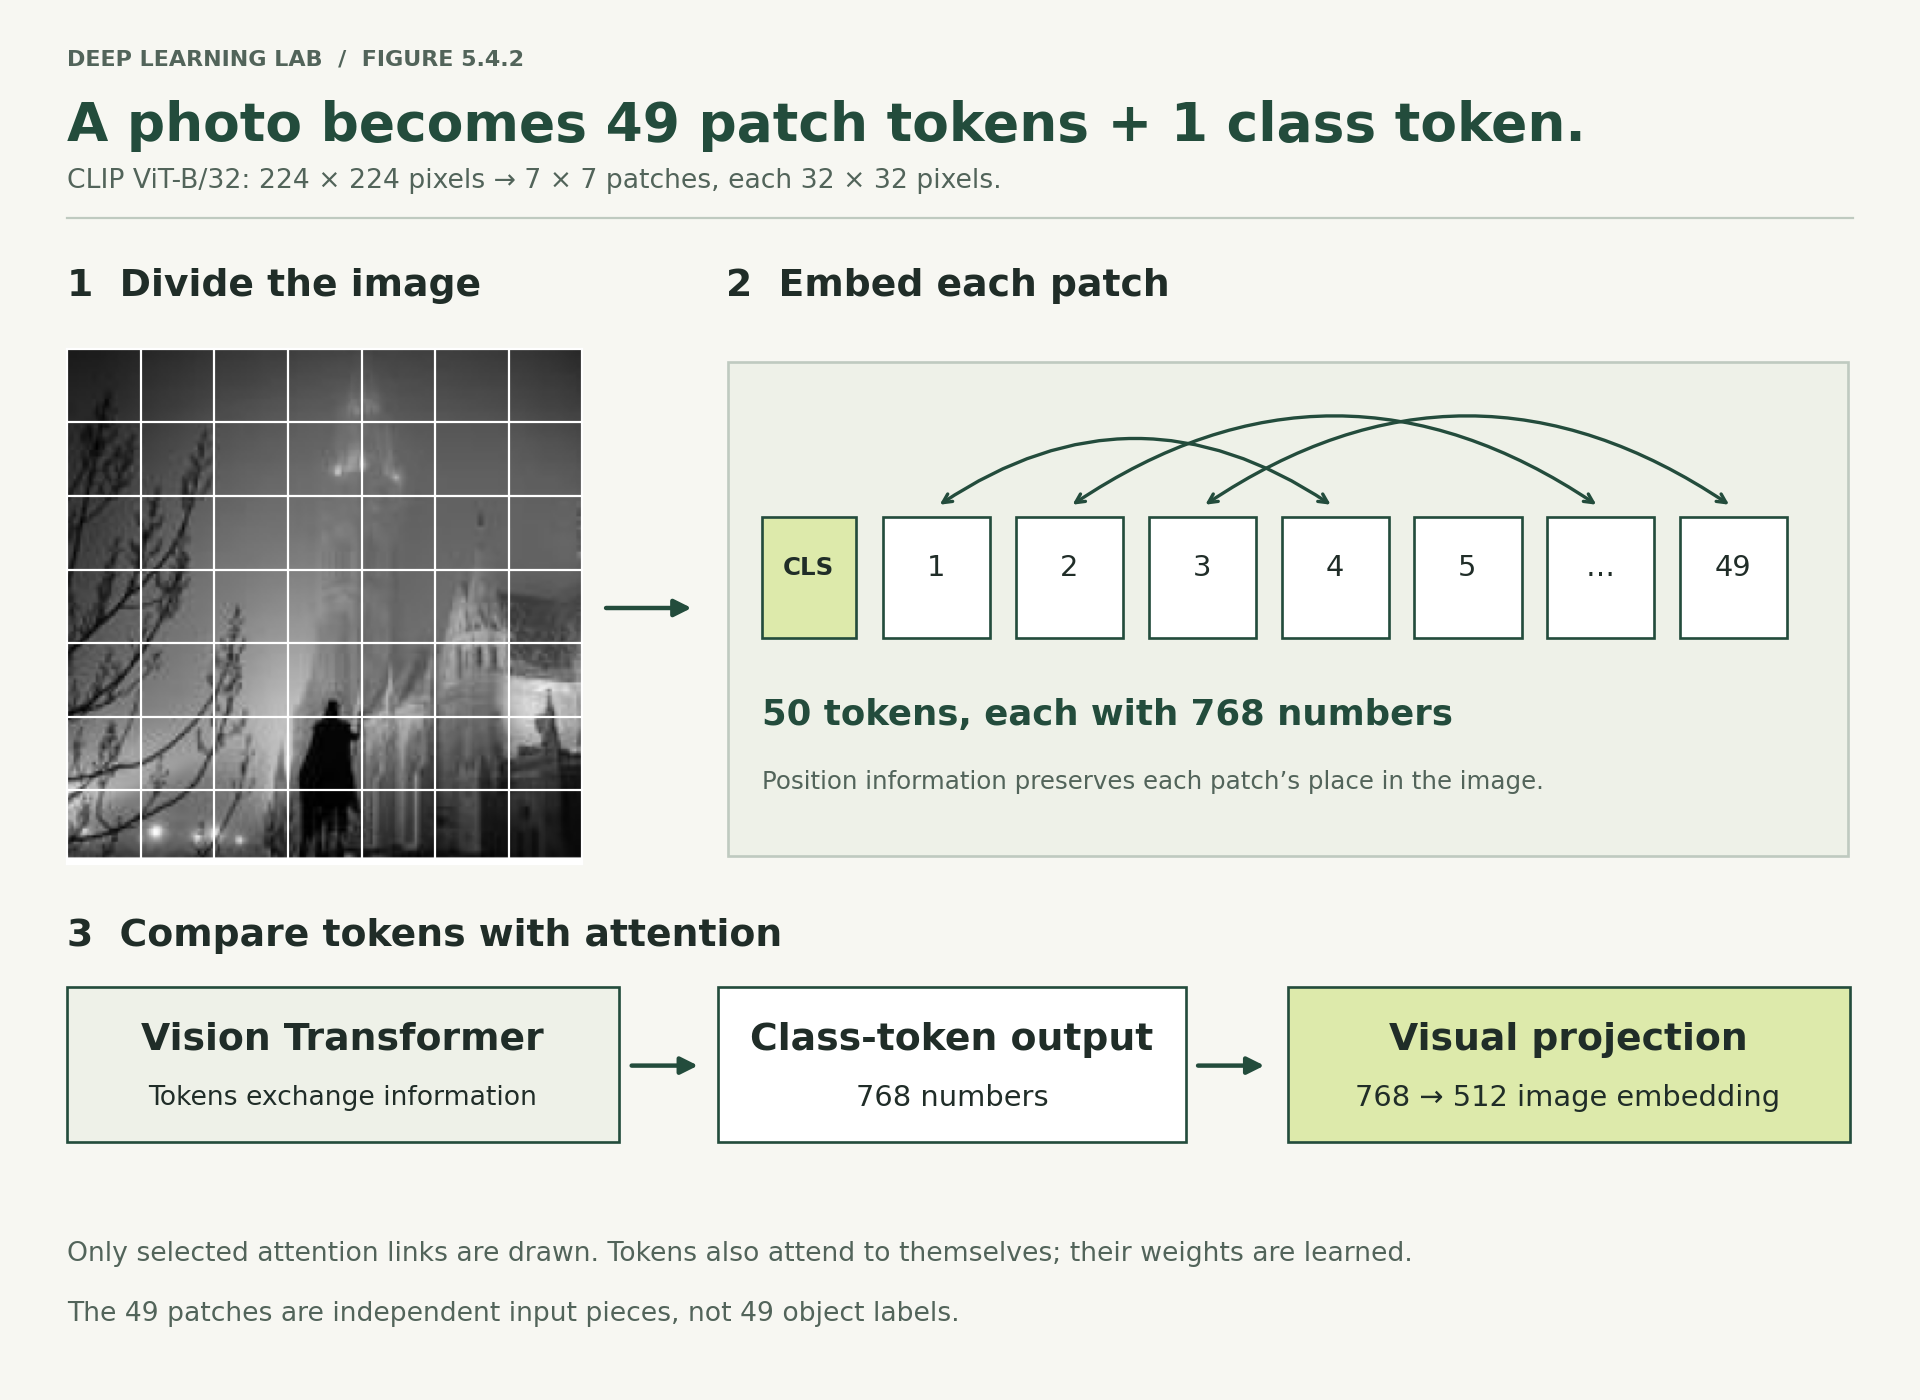

<p><b>Figure 5.4.2.</b> The lesson’s church photo is split into 49 patches. A class token makes 50 input tokens; the final class-token output is projected from 768 to 512 numbers.</p>

</div>

### Vision–language models, briefly

CLIP gives a shared space: it can tell you which sentence fits a photo, but it cannot *write* a sentence. **Vision–language models (VLMs)** connect an image encoder like CLIP's to a text-generating Transformer, so they can describe a photo or answer questions about it. They build on exactly the pieces in this note. Day 7 introduces them, and the Generative AI module uses them.

## 10. What to take away from Day 5

From this note:

- **CLIP** has an image encoder and a text encoder, trained together with **the contrastive loss from note 5.3** on photo–caption pairs, so photos and sentences share one space.
- **Zero-shot classification** is three steps: prompts from class names, embed everything, pick the closest prompt. No labelled examples needed.
- Prompt advice is a guess to test: on Imagenette, the "a photo of a ..." template did **not** beat bare class names.
- In one shared space you can **search photos with sentences**, and photos with photos.
- **Zero-shot breaks** when the class names and the photos are far from what CLIP saw on the web. On bean disease it scored below chance, and describing the leaves made it worse. CLIP's **photo** vectors still worked well with a few labelled examples. Testing each part separately told us *which side* failed.
- CLIP's photo vectors (0.8516) and note 5.1's ResNet-18 (0.7969) could **not** be told apart on 128 photos (sign test p = 0.2295). A gap that looks big can still be noise.
- CLIP's image encoder is a **Vision Transformer**: a photo becomes a sequence of patches, read like a sentence.

From the whole day:

```
 5.1  raw input → encoder → representation → task      learned encoders beat raw pixels and hand-made rules
 5.2  text → embedding                                 cosine similarity, search, and where embeddings fail
 5.3  learning without labels                          the contrastive loss, and when it pays off
 5.4  photos + text → one space                        zero-shot, cross-modal search, and its limits
```

Day 4 ended with gradient boosting winning on 15 columns that people had prepared. Day 5 answered the question it left open: for photos and text, the job of preparing good columns is done by a **learned encoder**, and you now know how to measure whether it did that job well.

### Next: Day 6 — Transformers

Three times today we treated a Transformer as a box: MiniLM's six layers in note 5.2, CLIP's text encoder, and CLIP's Vision Transformer just now. Every time, the box did the important work: turning a sequence of tokens or patches into vectors that know about each other. Day 6 opens the box. You will build **attention** by hand, see what queries, keys and values are, and put together a Transformer block, so that the next time you see "6 layers" or "49 patches", you know exactly what happens inside.